### AI Usage Disclosure:

I used AI tools as a helping tool while doing this project. AI helped me understand some coding parts, but the main ideas, analysis, and decisions were done by me.


###
In this project, I explored the Titanic dataset to understand the factors that influenced passenger survival.  
###
I first performed exploratory data analysis to study patterns in age, class, gender, and fare.  
###
Then, I created both good and  misleading visualizations to show how presentation can change interpretation.

In [107]:
# Import libraries
import warnings
warnings.filterwarnings("ignore")
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 1000)


In [108]:
# Load dataset
train = pd.read_csv("/content/train.csv")

print("Shape:", train.shape)
train.head()

Shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [109]:
train.isna().sum()


,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [110]:
train["Age"] = train["Age"].fillna(train["Age"].median())

In [111]:
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          891 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [112]:
train.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.361582,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,13.019697,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,22.000000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,35.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [113]:
#finding missing values
missing_count = train.isna().sum()
missing_percentage = (missing_count / len(train)) * 100

missing_table = pd.DataFrame({
    "Missing_Count": missing_count,
    "Missing_Percentage": missing_percentage.round(2)
})

missing_table[missing_table["Missing_Count"] > 0].sort_values(by="Missing_Count", ascending=False)

,Missing_Count,Missing_Percentage
Cabin,687,77.10
Embarked,2,0.22


In [114]:
#survival distribution
survival_distribution = train["Survived"].value_counts(normalize=True) * 100
survival_distribution

,proportion
Survived,
0,61.616162
1,38.383838


In [115]:
print("Gender Distribution:")
print(train["Sex"].value_counts())

print("\nPassenger Class Distribution:")
print(train["Pclass"].value_counts())

print("\nEmbarked Distribution:")
print(train["Embarked"].value_counts())

Gender Distribution:
Sex
male      577
female    314
Name: count, dtype: int64

Passenger Class Distribution:
Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Embarked Distribution:
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64


In [116]:
# color theme
PASTEL_BG     = "#FAF9F6"
TEXT_DARK     = "#3F3F3F"
P_BLUE        = "#A8DADC"
P_PINK        = "#FFAFCC"
P_PURPLE      = "#CDB4DB"
P_YELLOW      = "#FFF1B6"
P_GREEN       = "#BDE0FE"

plt.rcParams["figure.facecolor"] = PASTEL_BG
plt.rcParams["axes.facecolor"] = PASTEL_BG
plt.rcParams["axes.edgecolor"] = TEXT_DARK
plt.rcParams["axes.labelcolor"] = TEXT_DARK
plt.rcParams["xtick.color"] = TEXT_DARK
plt.rcParams["ytick.color"] = TEXT_DARK
plt.rcParams["text.color"] = TEXT_DARK

sns.set_style("white")

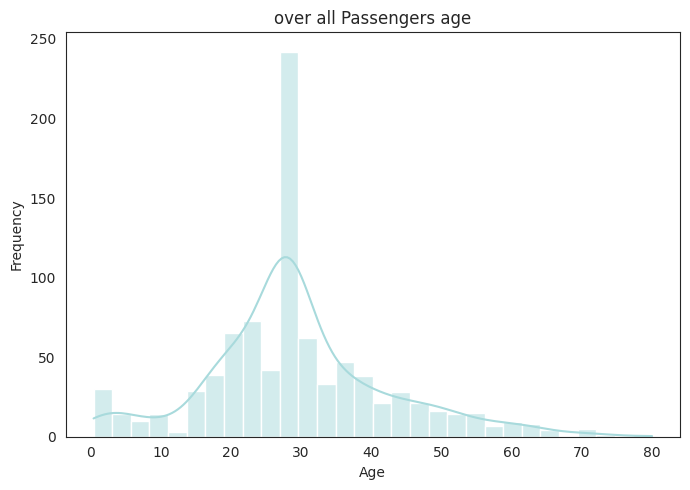

In [117]:
plt.figure(figsize=(7,5))

sns.histplot(
    train["Age"],
    bins=30,
    kde=True,
    color="#A8DADC"
)

plt.title("over all Passengers age")
plt.xlabel("Age")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

### This graph clearly shows how survival changes across gender and class. It presents the full data fairly without hiding or exaggerating anything.

In [118]:
# good graph - 1
pivot = train.pivot_table(
    index="Sex",
    columns="Pclass",
    values="Survived",
    aggfunc="mean"
) * 100



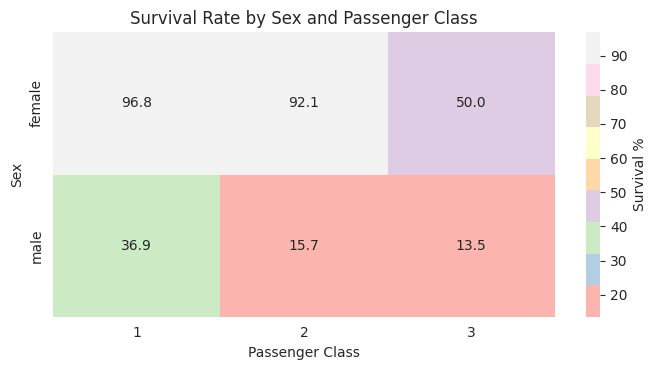

In [119]:
plt.figure(figsize=(7, 3.8))
sns.heatmap(
    pivot,
    annot=True,
    fmt=".1f",
    cmap="Pastel1",
    cbar_kws={"label": "Survival %"}
)

plt.title("Survival Rate by Sex and Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Sex")
plt.tight_layout()
plt.show()

### This graph compares fare patterns between survivors and non-survivors in a clear way.It shows the data without manipulating  presentation.

In [120]:
# good graph - 2
df = train.copy()
df["Fare"] = df["Fare"].fillna(df["Fare"].median())
def ecdf(x):
    x = np.sort(x)
    y = np.arange(1, len(x)+1) / len(x)
    return x, y
fare_dead = df.loc[df["Survived"] == 0, "Fare"]
fare_alive = df.loc[df["Survived"] == 1, "Fare"]
x0, y0 = ecdf(fare_dead)
x1, y1 = ecdf(fare_alive)


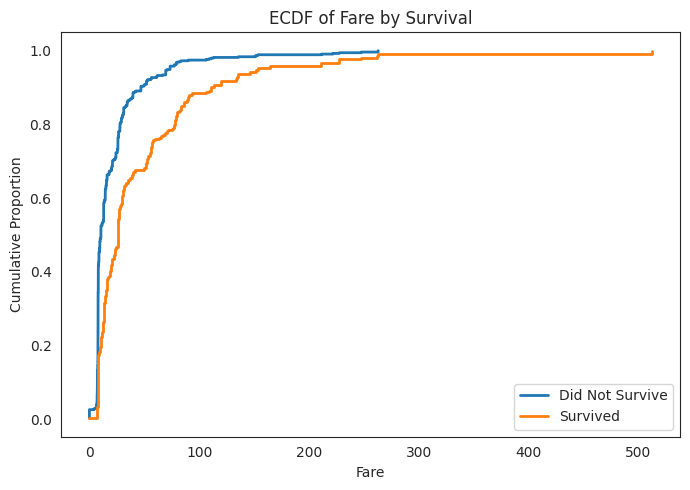

In [121]:
plt.figure(figsize=(7,5))
plt.step(x0, y0, where="post", label="Did Not Survive", linewidth=2)
plt.step(x1, y1, where="post", label="Survived", linewidth=2)

plt.title("ECDF of Fare by Survival")
plt.xlabel("Fare")
plt.ylabel("Cumulative Proportion")
plt.legend()
plt.tight_layout()
plt.show()

### This graph looks at survival based on passenger titles like Mr, Mrs, and Miss.All groups are included, and the comparison is shown.

In [122]:
# good graph - 3
df = train.copy()

df["Title"] = df["Name"].str.extract(r",\s*([^\.]+)\.", expand=False).str.strip()


top_titles = df["Title"].value_counts().head(6).index
df["Title_clean"] = np.where(df["Title"].isin(top_titles), df["Title"],"other")

title_survival = (df.groupby("Title_clean")["Survived"].mean() * 100).sort_values(ascending=False)



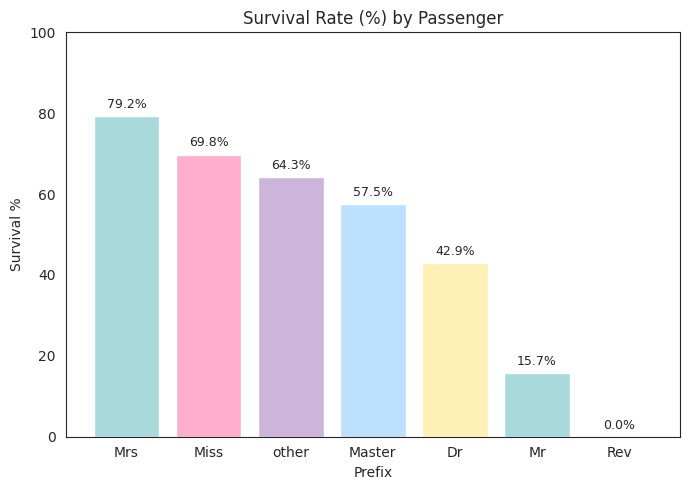

In [123]:
plt.figure(figsize=(7,5))
plt.bar(title_survival.index, title_survival.values, color=[P_BLUE, P_PINK, P_PURPLE, P_GREEN, P_YELLOW, P_BLUE, P_PINK])

plt.title("Survival Rate (%) by Passenger")
plt.xlabel("Prefix")
plt.ylabel("Survival %")
plt.ylim(0, 100)

for i, v in enumerate(title_survival.values):
    plt.text(i, v + 2, f"{v:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### This graph shows how survival changes depending on family size.The data is presented clearly without distorting the numbers.

In [124]:
# good graph - 4
df = train.copy()
df["FamilySize"] = df["SibSp"] + df["Parch"] + 1
df["FamilySizeCapped"] = df["FamilySize"].clip(upper=6)

rate = df.groupby("FamilySizeCapped")["Survived"].mean() * 100

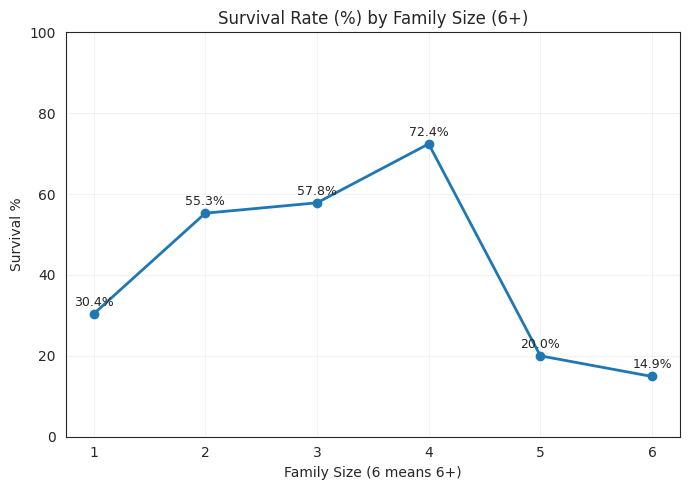

In [125]:
plt.figure(figsize=(7,5))
plt.plot(rate.index, rate.values, marker="o", linewidth=2)

plt.title("Survival Rate (%) by Family Size (6+)")
plt.xlabel("Family Size (6 means 6+)")
plt.ylabel("Survival %")
plt.ylim(0, 100)
plt.grid(alpha=0.25)

for x, y in zip(rate.index, rate.values):
    plt.text(x, y + 2, f"{y:.1f}%", ha="center", fontsize=9)

plt.tight_layout()
plt.show()

### This graph removes third-class passengers, which changes the graph.By leaving out a large group, it makes survival seem better than it actually was.

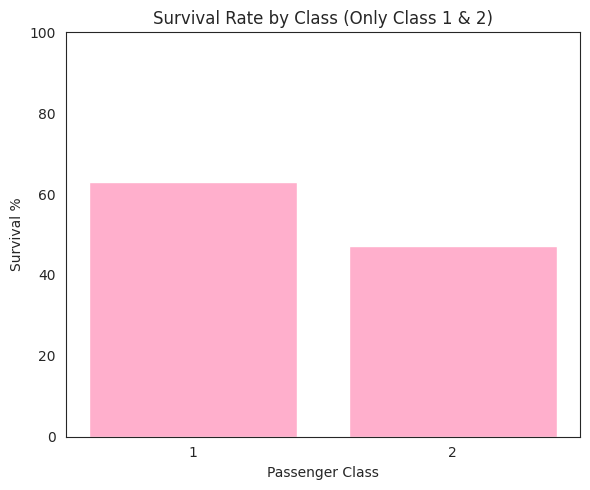

In [126]:
# cherry picking class 3 is removed bad graph-1
df_mis = train[train["Pclass"] != 3]

rate_subset = df_mis.groupby("Pclass")["Survived"].mean() * 100

plt.figure(figsize=(6,5))
plt.bar(rate_subset.index.astype(str), rate_subset.values, color="#FFAFCC")

plt.title("Survival Rate by Class (Only Class 1 & 2)")
plt.xlabel("Passenger Class")
plt.ylabel("Survival %")
plt.ylim(0,100)

plt.tight_layout()
plt.show()

### The color scale  makes small differences look much bigger.Even though the numbers are correct, the visual impact is misleading.

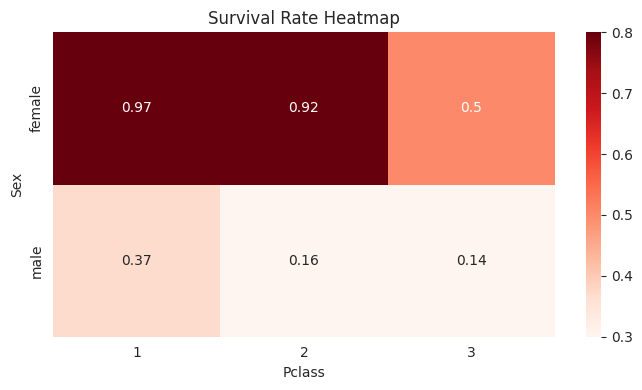

In [127]:
# Distored heatmap bad graph -2
pivot = train.pivot_table(
    index="Sex",
    columns="Pclass",
    values="Survived",
    aggfunc="mean"
)

plt.figure(figsize=(7,4))
sns.heatmap(
    pivot,
    annot=True,
    cmap="Reds",
    vmin=0.30,
    vmax=0.80
)

plt.title("Survival Rate Heatmap")
plt.tight_layout()
plt.show()

### The filled area makes the difference between groups look larger than it is.The design creates visuals that can change  perception.

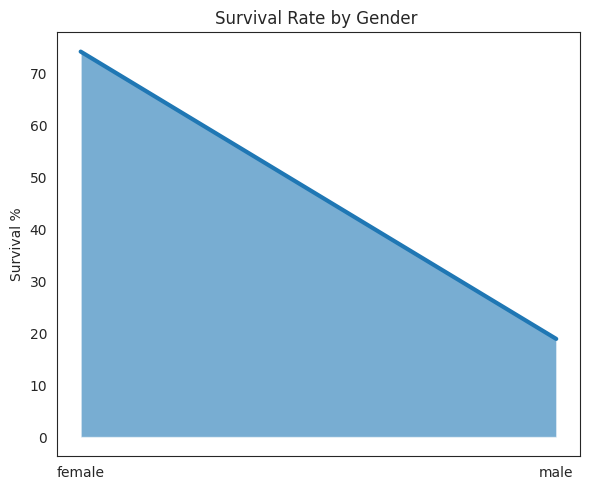

In [128]:
# Area chat bad graph - 3
gender_rate = train.groupby("Sex")["Survived"].mean() * 100

plt.figure(figsize=(6,5))
plt.fill_between(
    gender_rate.index,
    gender_rate.values,
    alpha=0.6
)

plt.plot(gender_rate.index, gender_rate.values, linewidth=3)

plt.title("Survival Rate by Gender ")
plt.ylabel("Survival %")

plt.tight_layout()
plt.show()

### This chart makes it harder to compare proportions accurately.It looks good, but it is not the clearest way to show the data.

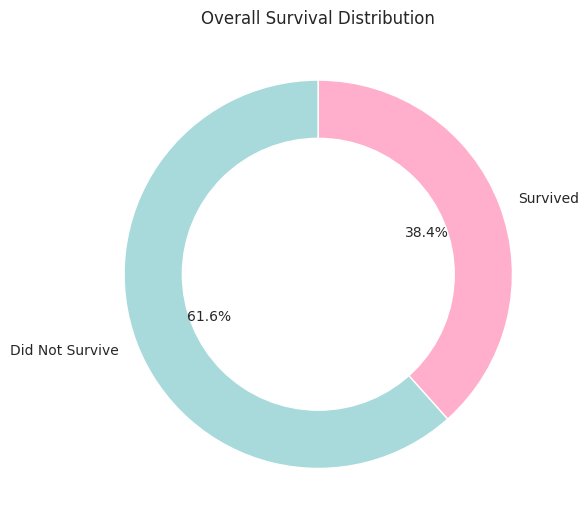

In [129]:
# bad graph -4
survival_counts = train["Survived"].value_counts()

plt.figure(figsize=(6,6))
plt.pie(
    survival_counts,
    labels=["Did Not Survive", "Survived"],
    autopct="%1.1f%%",
    startangle=90,
    colors=["#A8DADC", "#FFAFCC"]
)

centre_circle = plt.Circle((0,0),0.70,fc='white')
fig = plt.gcf()
fig.gca().add_artist(centre_circle)

plt.title("Overall Survival Distribution")
plt.tight_layout()
plt.show()